# Ray-Tracing Algorithm

We use the lens equation to propagate a bundle of light rays from the observer position to the source plane through a regular grid covering the lens plane.

For each ray passing at the position $\vec x_{ij}$ (lens plane), we evaluate the defelction angle $\vec\alpha(\vec x_{ij})$ and compute the arrival position on the source plane as 
$$ \vec y_{ij} = \vec x_{ij} - \vec\alpha(\vec x_{ij}) $$
This example uses a lens at redshift $z_L = 0.5$ and a source at redshift $z_S = 9$.

In [71]:
import numpy as np
import scipy as sp
from scipy.ndimage import map_coordinates
from astropy.io import fits
import matplotlib.pyplot as plt

In [72]:
# initiaise arrays for defelction angles
# (these can be calculated using the lens class in /Light.Deflection path)
angi = np.zeros(shape=(512,512))
angj = np.zeros(shape=(512,512))

In [73]:
npix = angi.shape[0]
i_range = np.linspace(0.0, 1.0, npix) * (npix-1) # define i coordinates
j_range = np.linspace(0.0, 1.0, npix) * (npix-1) # define j coordinates
i, j = np.meshgrid(i_range,j_range)

In [74]:
yi = i - angi
yj = j - angj

In order to improve the visualization of the results, we down-sample the maps by tracing a lower number of rays through the lens plane. More precisely, we reduce the number of grid points on the lens plane mesh by a factor ndown.

In [75]:
ndown = 16
npix_ = int(npix/ndown)

i_range = np.linspace(0.0, 1.0, npix_) * (npix-1) # down samples xi coordinates
j_range = np.linspace(0.0, 1.0, npix_) * (npix-1) # down samples xj coordinates
i, j = np.meshgrid(i_range,j_range) # downsampled grid

Using the `map_coordinate` method in scipy we interpolate angi and angj to calculate deflection angleson down-sampled grid

In [76]:
# reshape i and j
i_ = np.reshape(i, i.size) 
j_ = np.reshape(j, j.size)

# interpolate
angi_ = map_coordinates(angi, [[j],[i]], order=1)
angj_ = map_coordinates(angj, [[j],[i]], order=1)

# reshape angles back to mesh
angi = angi_.reshape( (npix_, npix_) ) 
angj = angj_.reshape( (npix_, npix_) ) 

and now apply lens equation

In [77]:
yi = i - angi
yj = j - angj

# Lets Try It

In [78]:
import numpy as np
from numpy import fft
from astropy.io import fits

class Deflector:
    """
    Given a convergence map in a FITS file, construct a Deflector object.

    This class computes the gravitational deflection angles from a convergence map.

    Methods
    -------
    deflection_map() -> array, array
        Returns two arrays: deflection in the x direction and y direction.

    image() -> array
        Returns the convergence map.
    """

    def __init__(self, filekappa: str, pad: bool = False, padwidth: float = 0.5):
        """
        Initialize a Deflector object from a convergence map.

        Parameters
        ----------
        filekappa : str
            Filename or path to the convergence map (FITS file).
        pad : bool, optional
            If True, pad the convergence map boundaries (default is False).
        padwidth : float, optional
            Width of padding applied to the map if `pad` is True (default is 0.5).
        """
        self.kappa, self.header = fits.getdata(filekappa, header=True) #type:ignore
        self.nopad_nx, self.nopad_ny = self.kappa.shape
        self.padwidth = padwidth
        if pad:
            self.pad()
        self.nx, self.ny = self.kappa.shape
        self.kx, self.ky = self.kernel()


    def pad(self) -> None:
        """
        Pad the convergence map with zeros.

        This ensures that the boundaries are non-periodic for Fourier transforms,
        which prevents wrap-around artifacts in the calculation.

        Notes
        -----
        The amount of padding is determined by `self.padwidth`, which is a fraction
        of the map size in each dimension.
        """
        px, py = self.kappa.shape

        pad_x = int(px * self.padwidth)
        pad_y = int(py * self.padwidth)
        
        self.kappa = np.pad(
            self.kappa,
            ((pad_x, pad_x), (pad_y, pad_y)),
            mode='constant',
            constant_values=0
        )

    def kernel(self):
        """
        Initialize the kernel array used for convolution with the convergence map.

        The kernel is a vector-valued function:

            K(x) = x / |x|^2 

        where `x` is the 2D position vector in the map.

        Notes
        -----
        - The size of the kernel matches the (optionally padded) convergence map.
        - This ensures that the kernel and the map can be convolved using
        element-wise multiplication in Fourier space.
        """
        kx = fft.fftfreq(self.nx).reshape(-1,1)
        ky = fft.fftfreq(self.ny).reshape(1,-1)

        den = kx**2 + ky**2
        den += 1e-12

        kx_kernel = -1j * kx / den
        ky_kernel = -1j * ky / den

        return kx_kernel, ky_kernel

    def deflection_map(self) -> tuple[np.ndarray, np.ndarray]:
        """
        Compute the deflection angle maps from the convergence map.

        The deflection is a convolution of the kernel and the convergence map (see Meneghetti notes).
        We use NumPy's fft library to convolve the two and compute deflection.

        Returns
        -------
        alpha_x : ndarray
            Deflection in the x-direction for each pixel [radians].
        alpha_y : ndarray
            Deflection in the y-direction for each pixel [radians].

        Notes
        -----
        - The FFT-based computation assumes periodic boundary conditions, 
        so you may want to pad the map using `self.pad()` to reduce wrap-around artifacts.
        - The returned arrays are real-valued; the imaginary part from FFT/IFFT is discarded.
        - The kernel is already in fourier space.
        """
        kappa_fft = fft.fft2(self.kappa)

        alpha_x_fft = kappa_fft * self.kx
        alpha_y_fft = kappa_fft * self.ky

        alpha_x = fft.ifft2(alpha_x_fft).real / np.pi
        alpha_y = fft.ifft2(alpha_y_fft).real / np.pi

        return alpha_x, alpha_y

    def image(self) -> np.ndarray:
        """
        Return the convergence map stored in the Deflector object.

        Returns
        -------
        kappa : ndarray
            The 2D array representing the convergence map used for deflection calculations.

        Notes
        -----
        - If padding was applied during initialization, this returns the padded map.
        """
        return self.kappa
    
    def map_crop(self, arr : np.ndarray):
        """
        Given an array `arr`, this method returns the unpadded version based on the size of the 
        original convergence map.

        Returns
        -------
        cropped_map : ndarray
            The 2D array representing the deflection map of the original section of space.
        """
        px, py = self.kappa.shape

        pad_x = int(px * self.padwidth)//2
        pad_y = int(py * self.padwidth)//2

        map_crop = arr[pad_y:pad_y+self.nopad_ny,pad_x:pad_x+self.nopad_nx]
        return map_crop





In [79]:
file = 'mass_distributions/kappa.01.017.fits'
df = Deflector(file,pad=True)
df.kappa = df.kappa * 20
angi, angj = df.deflection_map()

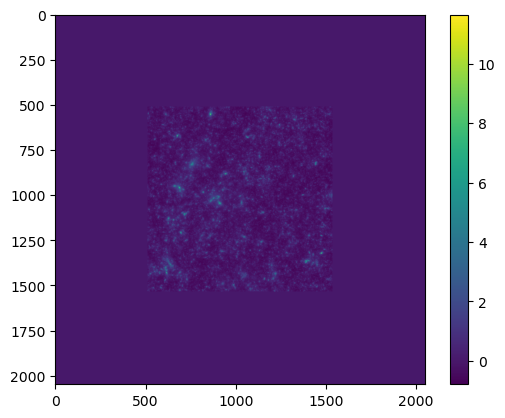

In [80]:
cbar = plt.imshow(df.image())
plt.colorbar(cbar)
plt.show()

In [81]:
ndown = 2
npix = angi.shape[0]
npix_ = int(npix/ndown)

i_range = np.linspace(0.0, 1.0, npix_) * (npix-1) # down samples xi coordinates
j_range = np.linspace(0.0, 1.0, npix_) * (npix-1) # down samples xj coordinates
i, j = np.meshgrid(i_range,j_range) # downsampled grid

In [82]:
# reshape i and j
i_ = np.reshape(i, i.size) 
j_ = np.reshape(j, j.size)

# interpolate
angi_ = map_coordinates(angi, [[j],[i]], order=1)
angj_ = map_coordinates(angj, [[j],[i]], order=1)

# reshape angles back to mesh
angi = angi_.reshape( (npix_, npix_) ) 
angj = angj_.reshape( (npix_, npix_) ) 

In [83]:
yi = i - angi
yj = j - angj

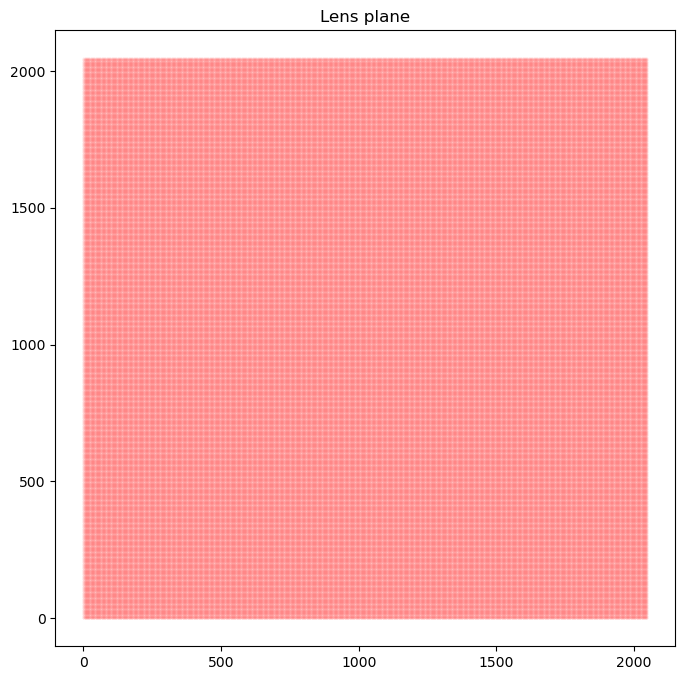

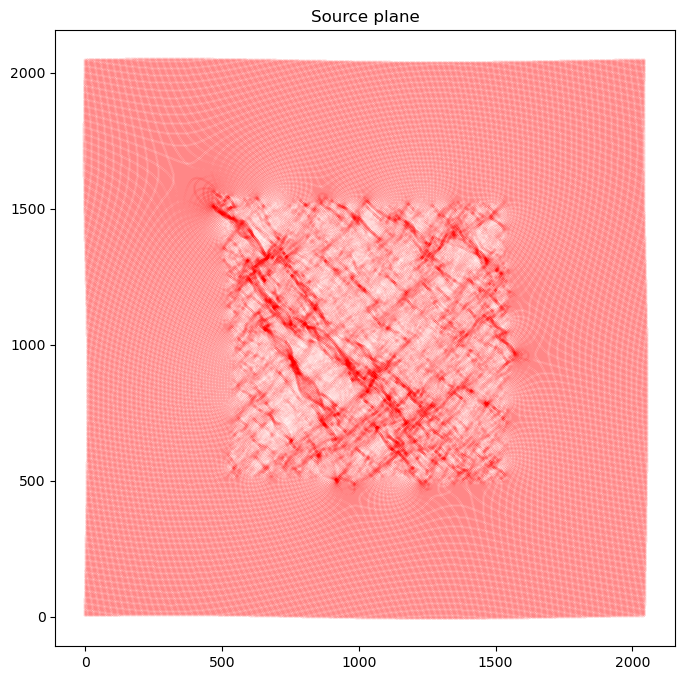

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(i, j, s=0.0005, c='red', alpha=1)     # scatter on top
plt.title("Lens plane")
plt.show()


plt.figure(figsize=(8, 8))
plt.scatter(yi, yj, s=0.0005, c='red', alpha=1)     # scatter on top
plt.title("Source plane")
plt.show()
